# Importing Libraries

In [28]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
# from google.colab import drive
# drive.mount('/content/drive')
import seaborn as sb
import matplotlib.pyplot as plt
import plotly.express as px
import joblib

# Preparing and Loading the data

In [2]:
df1 = pd.read_csv("./prevalence-by-mental-and-substance-use-disorder.csv")
df2 = pd.read_csv("./mental-and-substance-use-as-share-of-disease.csv")

In [3]:
df1.head()

,Entity,Code,Year,Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent)
0,Afghanistan,AFG,1990,0.228979,0.721207,0.131001,4.835127,0.454202,5.125291,0.444036
1,Afghanistan,AFG,1991,0.228120,0.719952,0.126395,4.821765,0.447112,5.116306,0.444250
2,Afghanistan,AFG,1992,0.227328,0.718418,0.121832,4.801434,0.441190,5.106558,0.445501
3,Afghanistan,AFG,1993,0.226468,0.717452,0.117942,4.789363,0.435581,5.100328,0.445958
4,Afghanistan,AFG,1994,0.225567,0.717012,0.114547,4.784923,0.431822,5.099424,0.445779


In [4]:
df2.head(10)

,Entity,Code,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
0,Afghanistan,AFG,1990,1.696670
1,Afghanistan,AFG,1991,1.734281
2,Afghanistan,AFG,1992,1.791189
3,Afghanistan,AFG,1993,1.776779
4,Afghanistan,AFG,1994,1.712986
5,Afghanistan,AFG,1995,1.738272
6,Afghanistan,AFG,1996,1.778098
7,Afghanistan,AFG,1997,1.781815
8,Afghanistan,AFG,1998,1.729402
9,Afghanistan,AFG,1999,1.850988


In [5]:
data = pd.merge(df1,df2)
data.head(10)

,Entity,Code,Year,Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent),DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
0,Afghanistan,AFG,1990,0.228979,0.721207,0.131001,4.835127,0.454202,5.125291,0.444036,1.696670
1,Afghanistan,AFG,1991,0.228120,0.719952,0.126395,4.821765,0.447112,5.116306,0.444250,1.734281
2,Afghanistan,AFG,1992,0.227328,0.718418,0.121832,4.801434,0.441190,5.106558,0.445501,1.791189
3,Afghanistan,AFG,1993,0.226468,0.717452,0.117942,4.789363,0.435581,5.100328,0.445958,1.776779
4,Afghanistan,AFG,1994,0.225567,0.717012,0.114547,4.784923,0.431822,5.099424,0.445779,1.712986
5,Afghanistan,AFG,1995,0.224713,0.716686,0.111129,4.780851,0.428578,5.098495,0.445422,1.738272
6,Afghanistan,AFG,1996,0.223690,0.716388,0.107786,4.777272,0.426393,5.100580,0.444837,1.778098
7,Afghanistan,AFG,1997,0.222424,0.716143,0.103931,4.775242,0.423720,5.105474,0.443938,1.781815
8,Afghanistan,AFG,1998,0.221129,0.716139,0.100343,4.777377,0.422491,5.113707,0.442665,1.729402
9,Afghanistan,AFG,1999,0.220065,0.716323,0.097946,4.782067,0.421215,5.120480,0.441428,1.850988


# Data Cleaning

In [6]:
data.isnull().sum()

Entity                                                                                               0
Code                                                                                               690
Year                                                                                                 0
Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent)                             0
Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent)                          0
Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent)                          0
Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent)                         0
Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent)                        0
Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent)                      0
Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (P

In [7]:
data.drop('Code', axis=1, inplace=True)
data.head(10)

,Entity,Year,Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent),DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
0,Afghanistan,1990,0.228979,0.721207,0.131001,4.835127,0.454202,5.125291,0.444036,1.696670
1,Afghanistan,1991,0.228120,0.719952,0.126395,4.821765,0.447112,5.116306,0.444250,1.734281
2,Afghanistan,1992,0.227328,0.718418,0.121832,4.801434,0.441190,5.106558,0.445501,1.791189
3,Afghanistan,1993,0.226468,0.717452,0.117942,4.789363,0.435581,5.100328,0.445958,1.776779
4,Afghanistan,1994,0.225567,0.717012,0.114547,4.784923,0.431822,5.099424,0.445779,1.712986
5,Afghanistan,1995,0.224713,0.716686,0.111129,4.780851,0.428578,5.098495,0.445422,1.738272
6,Afghanistan,1996,0.223690,0.716388,0.107786,4.777272,0.426393,5.100580,0.444837,1.778098
7,Afghanistan,1997,0.222424,0.716143,0.103931,4.775242,0.423720,5.105474,0.443938,1.781815
8,Afghanistan,1998,0.221129,0.716139,0.100343,4.777377,0.422491,5.113707,0.442665,1.729402
9,Afghanistan,1999,0.220065,0.716323,0.097946,4.782067,0.421215,5.120480,0.441428,1.850988


In [8]:
data.size,data.shape

(68400, (6840, 10))

In [9]:
data.head(10)

,Entity,Year,Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent),DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
0,Afghanistan,1990,0.228979,0.721207,0.131001,4.835127,0.454202,5.125291,0.444036,1.696670
1,Afghanistan,1991,0.228120,0.719952,0.126395,4.821765,0.447112,5.116306,0.444250,1.734281
2,Afghanistan,1992,0.227328,0.718418,0.121832,4.801434,0.441190,5.106558,0.445501,1.791189
3,Afghanistan,1993,0.226468,0.717452,0.117942,4.789363,0.435581,5.100328,0.445958,1.776779
4,Afghanistan,1994,0.225567,0.717012,0.114547,4.784923,0.431822,5.099424,0.445779,1.712986
5,Afghanistan,1995,0.224713,0.716686,0.111129,4.780851,0.428578,5.098495,0.445422,1.738272
6,Afghanistan,1996,0.223690,0.716388,0.107786,4.777272,0.426393,5.100580,0.444837,1.778098
7,Afghanistan,1997,0.222424,0.716143,0.103931,4.775242,0.423720,5.105474,0.443938,1.781815
8,Afghanistan,1998,0.221129,0.716139,0.100343,4.777377,0.422491,5.113707,0.442665,1.729402
9,Afghanistan,1999,0.220065,0.716323,0.097946,4.782067,0.421215,5.120480,0.441428,1.850988


In [10]:
data.columns = ["Country","Year","Schizophrenia","Bipolar-disorder","Eating-disorders","Anxiety-disorders","Drug-use disorders","Depressive-disorders","Alcohol-use disorders","Mental-Fitness"]

In [11]:
data.head(100)

,Country,Year,Schizophrenia,Bipolar-disorder,Eating-disorders,Anxiety-disorders,Drug-use disorders,Depressive-disorders,Alcohol-use disorders,Mental-Fitness
0,Afghanistan,1990,0.228979,0.721207,0.131001,4.835127,0.454202,5.125291,0.444036,1.696670
1,Afghanistan,1991,0.228120,0.719952,0.126395,4.821765,0.447112,5.116306,0.444250,1.734281
2,Afghanistan,1992,0.227328,0.718418,0.121832,4.801434,0.441190,5.106558,0.445501,1.791189
3,Afghanistan,1993,0.226468,0.717452,0.117942,4.789363,0.435581,5.100328,0.445958,1.776779
4,Afghanistan,1994,0.225567,0.717012,0.114547,4.784923,0.431822,5.099424,0.445779,1.712986
...,...,...,...,...,...,...,...,...,...,...
95,Algeria,1995,0.261108,0.793378,0.195046,4.857070,0.367362,4.398319,0.439044,5.192361
96,Algeria,1996,0.261122,0.793524,0.195062,4.858773,0.371340,4.392500,0.439044,5.460333
97,Algeria,1997,0.261182,0.793696,0.194193,4.861148,0.374676,4.389075,0.439293,5.505331
98,Algeria,1998,0.261284,0.793916,0.193329,4.864047,0.378961,4.384181,0.439626,5.729461


#Visualization

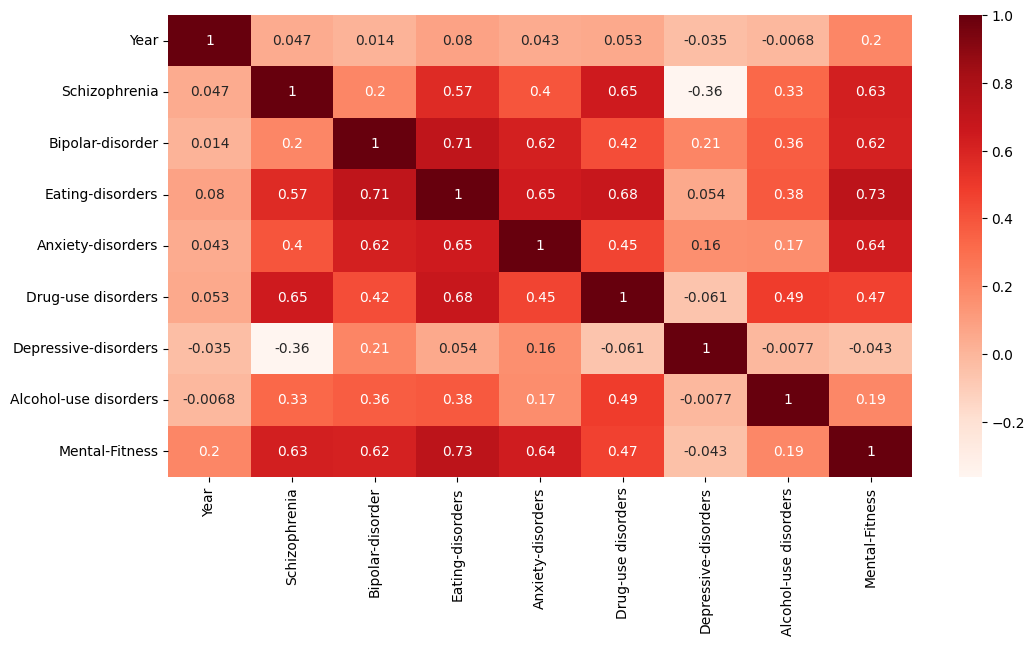

In [12]:
# plt.figure(figsize=(12,6))
# sb.heatmap(data.corr(),annot=True,cmap='Reds')
# plt.plot()
plt.figure(figsize=(12,6))
numeric_data = data.select_dtypes(include=["number"])  # select only numerical columns
sb.heatmap(numeric_data.corr(), annot=True, cmap='Reds')
plt.show()


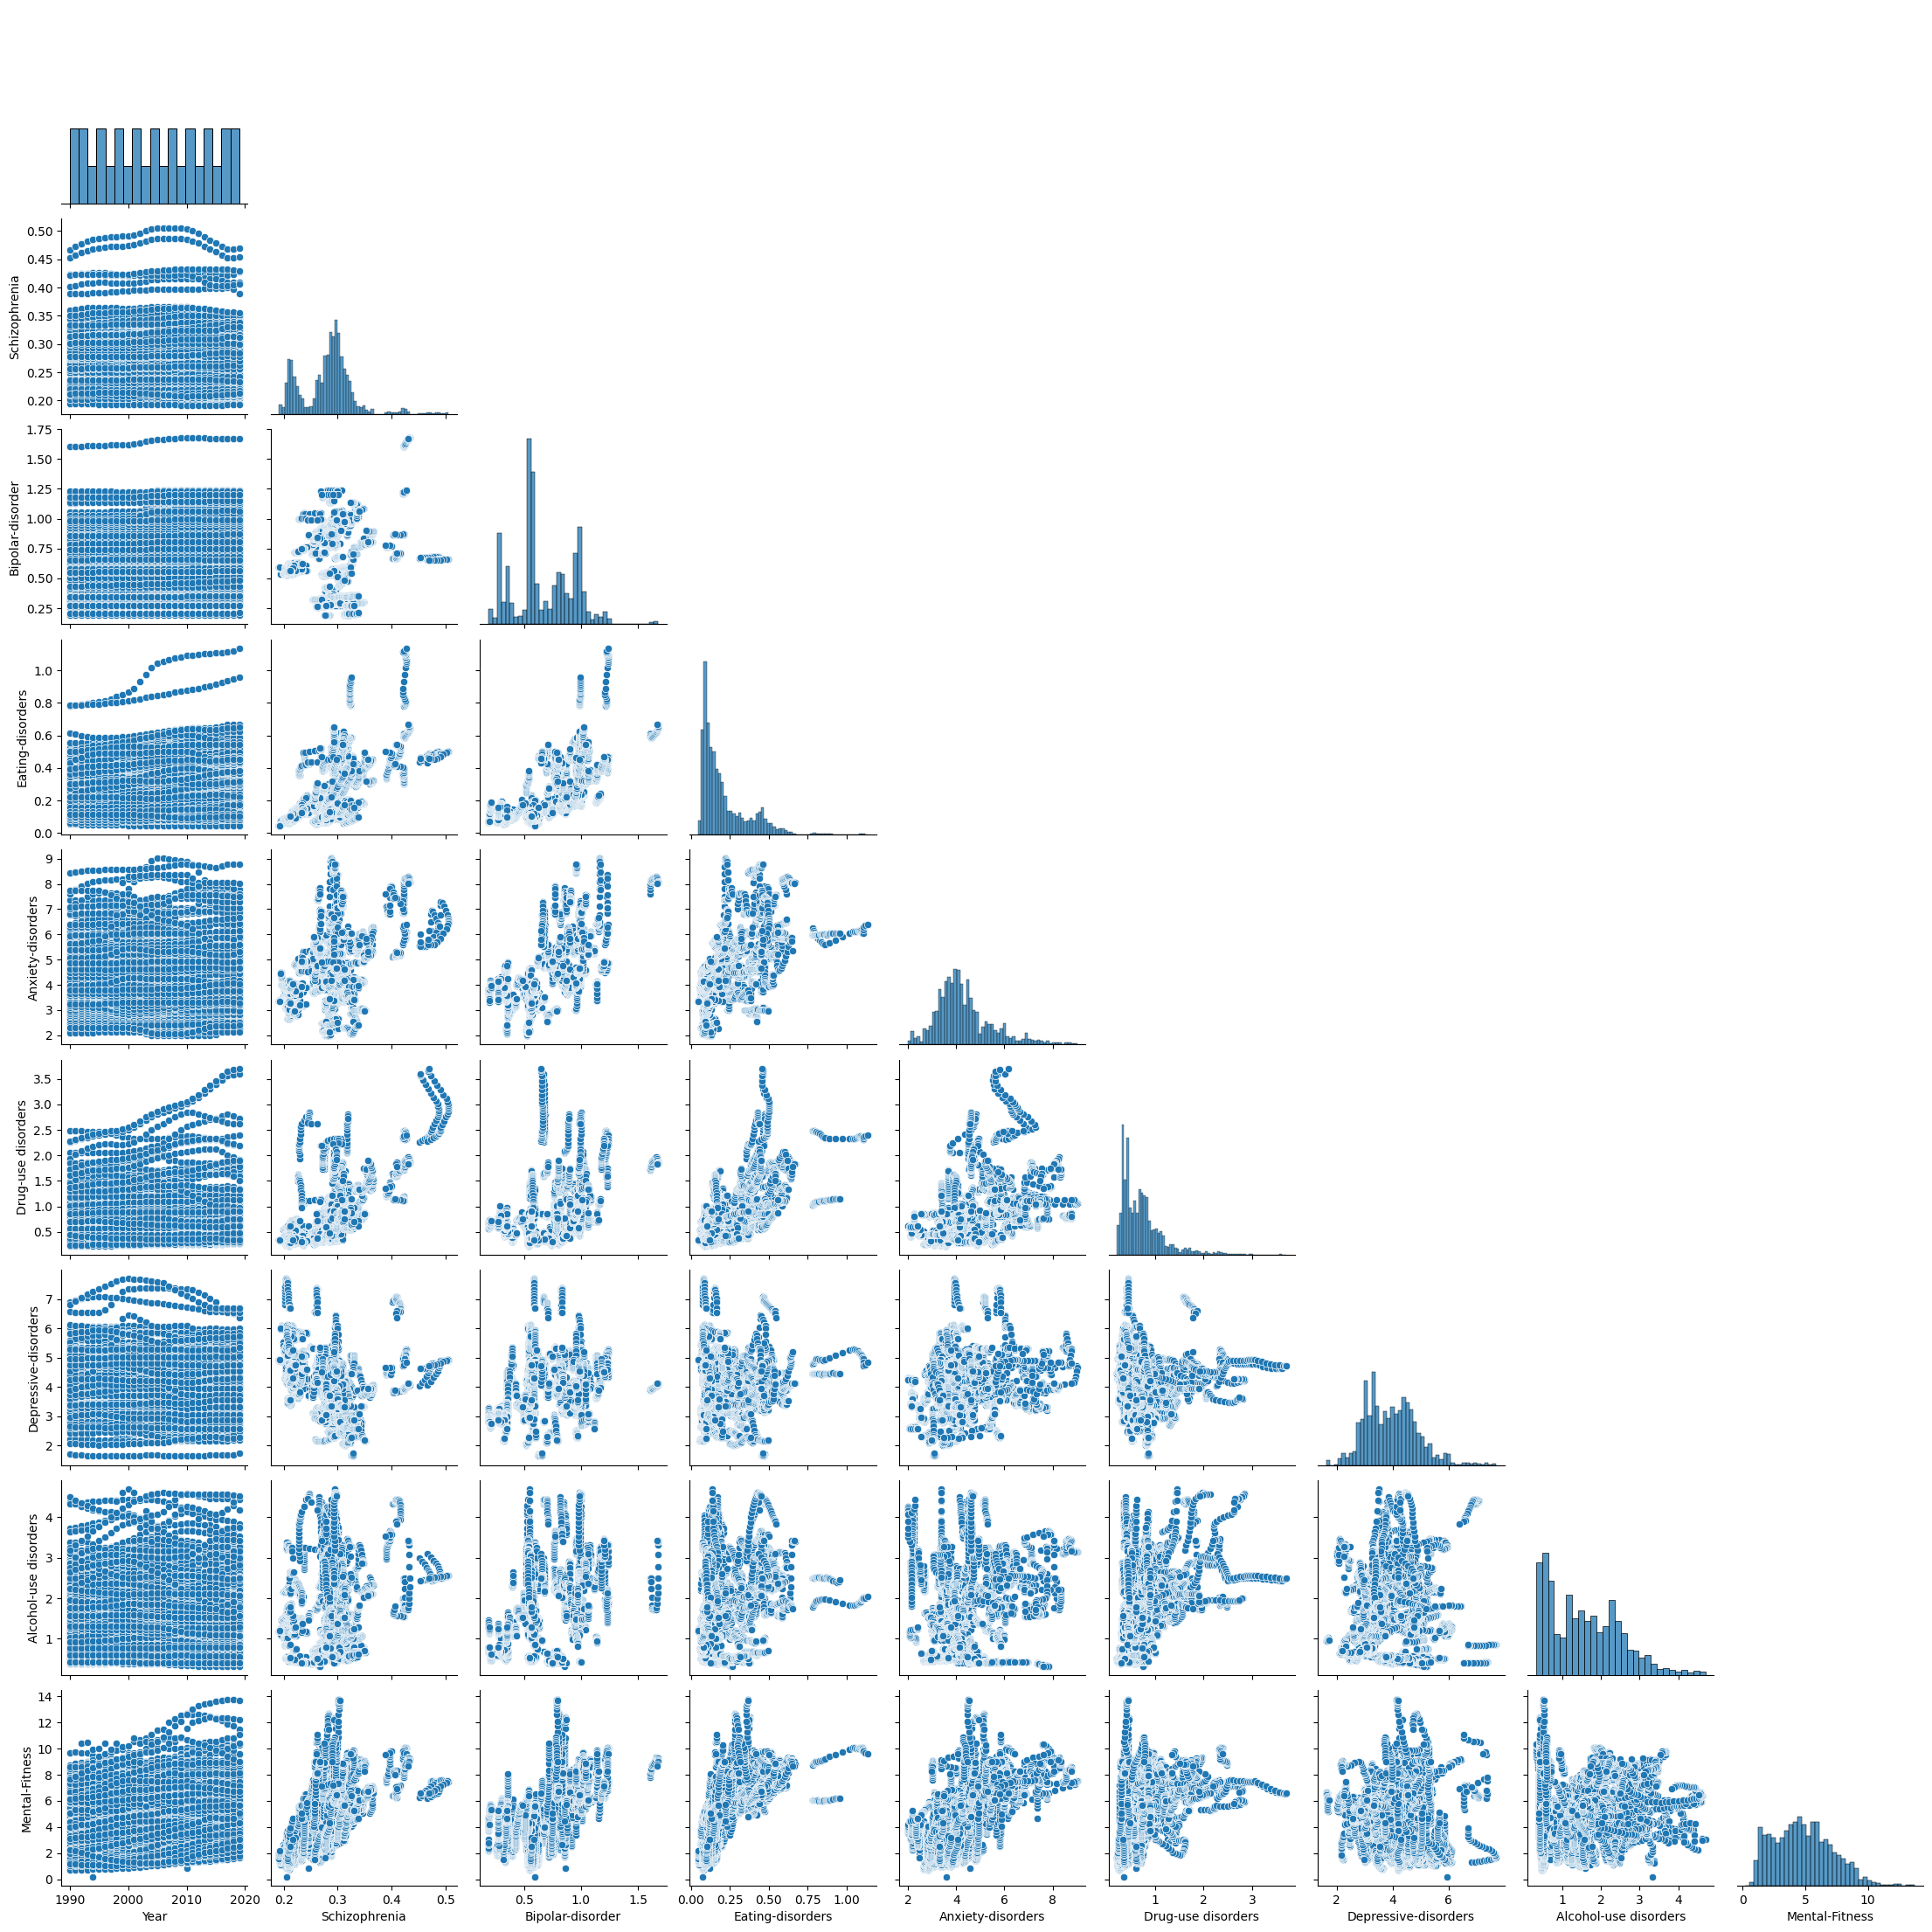

In [13]:
sb.pairplot(data,corner=True)
plt.show()

In [14]:
mean = data["Mental-Fitness"].mean()
mean

4.8180618117506135

In [16]:
Pie = px.pie(data, values="Mental-Fitness", names='Year')
Pie.show()

In [17]:
fig = px.box(data, x='Year', y='Mental-Fitness', title="Distribution of Mental Health Burden Over Years")
fig.show()

In [18]:
fig = px.line(data, x='Year', y = 'Mental-Fitness',
              color = 'Country', markers=True,
              color_discrete_sequence=['red','blue'],
              template='plotly_dark')
fig.show()

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6840 entries, 0 to 6839
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                6840 non-null   object 
 1   Year                   6840 non-null   int64  
 2   Schizophrenia          6840 non-null   float64
 3   Bipolar-disorder       6840 non-null   float64
 4   Eating-disorders       6840 non-null   float64
 5   Anxiety-disorders      6840 non-null   float64
 6   Drug-use disorders     6840 non-null   float64
 7   Depressive-disorders   6840 non-null   float64
 8   Alcohol-use disorders  6840 non-null   float64
 9   Mental-Fitness         6840 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 534.5+ KB


In [20]:
from sklearn.preprocessing import LabelEncoder
lab = LabelEncoder()
for i in data.columns:
  if data[i].dtype == 'object':
    data[i] = lab.fit_transform(data[i])

In [21]:
data.shape

(6840, 10)

#Split Data

In [22]:
x = data.drop('Mental-Fitness',axis=1)
y = data['Mental-Fitness']

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y , test_size=.20, random_state=2)

In [23]:
print("xtrain =", xtrain.shape)
print("xtest =", xtest.shape)
print()
print("ytrain =", ytrain.shape)
print("ytrain =", ytest.shape)

xtrain = (5472, 9)
xtest = (1368, 9)

ytrain = (5472,)
ytrain = (1368,)


#Model Training

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lr = LinearRegression()
lr.fit(xtrain,ytrain)

ytrain_pred = lr.predict(xtrain)
mse = mean_squared_error(ytrain,ytrain_pred)
rmse = (np.sqrt(mean_squared_error(ytrain,ytrain_pred)))
r2 = r2_score(ytrain,ytrain_pred)

print("The Linear Regression model performance for training set")
print("-------------------------------------------------")
print("MSE is {}".format(mse))
print("RMSE is {}".format(rmse))
print("R2 score is {}".format(r2))

The Linear Regression model performance for training set
-------------------------------------------------
MSE is 1.389959372405798
RMSE is 1.1789653821914357
R2 score is 0.7413245790025275


In [25]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(xtrain,ytrain)

ytrain_pred = rf.predict(xtrain)
mse = mean_squared_error(ytrain,ytrain_pred)
rmse = (np.sqrt(mean_squared_error(ytrain,ytrain_pred)))
r2 = r2_score(ytrain,ytrain_pred)

print("The Random Forest Regressor model performance for training set")
print("-------------------------------------------------")
print("MSE is {}".format(mse))
print("RMSE is {}".format(rmse))
print("R2 score is {}".format(r2))

The Random Forest Regressor model performance for training set
-------------------------------------------------
MSE is 0.00490070108823997
RMSE is 0.07000500759402838
R2 score is 0.9990879654885243


#Evaluation

In [26]:
ytest_pred = lr.predict(xtest)
mse = mean_squared_error(ytest,ytest_pred)
rmse = (np.sqrt(mean_squared_error(ytest,ytest_pred)))
r2 = r2_score(ytest,ytest_pred)

print("The Linear Regression model performance for training set")
print("-------------------------------------------------")
print("MSE is {}".format(mse))
print("RMSE is {}".format(rmse))
print("R2 score is {}".format(r2))

ytest_pred = rf.predict(xtest)
mse = mean_squared_error(ytest,ytest_pred)
rmse = (np.sqrt(mean_squared_error(ytest,ytest_pred)))
r2 = r2_score(ytest,ytest_pred)

print()

print("The Random Forest Regressor model performance for training set")
print("-------------------------------------------------")
print("MSE is {}".format(mse))
print("RMSE is {}".format(rmse))
print("R2 score is {}".format(r2))

# garph add

The Linear Regression model performance for training set
-------------------------------------------------
MSE is 1.1357545319272382
RMSE is 1.0657178481789813
R2 score is 0.7638974087055274

The Random Forest Regressor model performance for training set
-------------------------------------------------
MSE is 0.0287801322810928
RMSE is 0.1696470815578411
R2 score is 0.9940171369619514


#Result

In [27]:
print("Welcome to Mental Fitness Tracker!")

print("Fill the details to check your mental fitness!")



country_input = input("Enter Your country Name: ")



try:

    Country = lab.transform([country_input])[0]  # Use transform only, not fit_transform

except ValueError:

    print("Country not found in the training data. Please enter a valid country name.")

    exit()



Year = int(input("Enter the Year: "))

Schizophrenia = float(input("Enter your Schizophrenia rate in %: "))

Bipolar = float(input("Enter your Bipolar disorder rate in %: "))

Eating = float(input("Enter your Eating disorder rate in %: "))

Anxiety = float(input("Enter your Anxiety rate in %: "))

Drug_use = float(input("Enter your Drug Usage rate in per year %: "))

Depression = float(input("Enter your Depression rate in %: "))

Alcohol = float(input("Enter your Alcohol Consuming rate per year in %: "))



# Predict

prediction = rf.predict([[Country, Year, Schizophrenia, Bipolar, Eating, Anxiety, Drug_use, Depression, Alcohol]])

print(f"Your Mental Fitness is {prediction[0] * 10:.2f}%")

Welcome to MindBal: National Mental Health Burden Predictor
Analyze how disorder prevalence affects a country's health score.

--- Enter National Prevalence Rates (%) ---
(Example: 0.2 for Schizophrenia, 4.5 for Anxiety)

Analysis Result for India:
Projected Mental Health Burden (DALYs): 8.60%
Interpretation: A lower percentage indicates better overall national mental health.


#Saving the model

In [29]:
joblib.dump(rf, 'mindbal_model.pkl')

joblib.dump(lab, 'country_encoder.pkl')

print("Model and Encoder saved successfully!")

Model and Encoder saved successfully!
